# RQ3 temperature

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

# Data for each section
decision_direction_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [0.30, 0.02, 0.10, 0.52, 0.09, 0.26],
    # 'rouge2': [0.06, 0.16, 0.07, 0.10, 0.15, 0.20],
    'rougeL': [0.13, 0.12, 0.04, 0.14, 0.13, 0.32],
    'bert_f1': [0.23, 0.11, 0.15, 0.16, 0.08, 0.25],
    'align_score': [0.15, 0.24, 0.45, 0.32, 0.52, 0.05],
    'unieval_coherence': [0.21, 0.01, 0.24, 0.58, 1.78, 0.36],
    # 'unieval_consistency': [0.35, 0.28, 0.79, 0.21, 0.64, 0.25],
    'unieval_fluency': [0.42, 0.03, 0.17, 0.35, 0.05, 0.05]
}

issue_area_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [1.28, 1.33, 1.37, 1.62, 0.99, 1.20],
    # 'rouge2': [0.69, 0.57, 0.58, 0.83, 0.58, 0.44],
    'rougeL': [0.58, 0.69, 0.18, 0.50, 0.38, 0.57],
    'bert_f1': [0.60, 0.62, 0.56, 0.27, 0.53, 0.59],
    'align_score': [0.99, 1.28, 0.75, 1.12, 1.11, 0.94],
    'unieval_coherence': [4.60, 1.13, 2.41, 5.23, 2.30, 3.87],
    # 'unieval_consistency': [1.53, 1.74, 2.33, 1.66, 1.72, 2.04],
    'unieval_fluency': [1.69, 1.32, 0.68, 0.86, 0.80, 1.45]
}

party_winning_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [0.30, 0.12, 0.10, 0.11, 0.24, 0.61],
    # 'rouge2': [0.44, 0.30, 0.21, 0.28, 0.34, 0.00],
    'rougeL': [0.10, 0.03, 0.05, 0.00, 0.08, 0.16],
    'bert_f1': [0.17, 0.20, 0.19, 0.23, 0.20, 0.32],
    'align_score': [0.02, 0.18, 0.19, 0.14, 0.35, 0.05],
    'unieval_coherence': [0.03, 0.72, 1.85, 1.15, 0.27, 0.95],
    # 'unieval_consistency': [0.39, 0.06, 0.75, 0.15, 0.33, 0.45],
    'unieval_fluency': [0.11, 0.11, 0.29, 0.23, 0.44, 0.03]
}

vote_distribution_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [4.02, 4.85, 2.56, 1.29, 3.52, 2.81],
    # 'rouge2': [1.66, 2.55, 1.31, 1.06, 1.95, 1.55],
    'rougeL': [1.38, 1.72, 0.90, 1.37, 1.47, 1.23],
    'bert_f1': [0.40, 0.29, 0.26, 0.43, 0.40, 0.50],
    'align_score': [2.38, 1.85, 2.10, 1.99, 1.22, 1.30],
    'unieval_coherence': [3.01, 5.95, 2.28, 3.42, 5.04, 2.91],
    # 'unieval_consistency': [1.64, 1.71, 0.96, 1.67, 0.82, 1.68],
    'unieval_fluency': [0.50, 2.01, 1.12, 1.52, 1.80, 2.11]
}

respondent_type_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    # 'rouge1': [3.25, 0.84, 1.25, 2.05, 0.64, 0.85],
    # 'rouge2': [1.73, 0.65, 0.62, 1.68, 0.55, 0.42],
    'rougeL': [1.00, 0.77, 0.43, 1.00, 0.60, 0.70],
    'bert_f1': [1.14, 0.89, 1.09, 1.65, 0.77, 0.91],
    'align_score': [1.22, 1.68, 1.13, 0.77, 1.28, 1.64],
    'unieval_coherence': [4.57, 9.82, 5.95, 3.96, 10.00, 7.42],
    # 'unieval_consistency': [2.86, 2.60, 4.54, 0.88, 1.76, 1.36],
    'unieval_fluency': [1.21, 1.89, 3.52, 1.59, 1.70, 1.79]
}

# Create DataFrames
decision_direction_df = pd.DataFrame(decision_direction_data)
issue_area_df = pd.DataFrame(issue_area_data)
party_winning_df = pd.DataFrame(party_winning_data)
vote_distribution_df = pd.DataFrame(vote_distribution_data)
respondent_type_df = pd.DataFrame(respondent_type_data)



import matplotlib.pyplot as plt

def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    for column in df.columns[1:]:
        y = df[column]
        plt.plot(df['temp'], y, marker='o', label=column)
        
        # Highlight the minimum value
        min_value = y.min()
        min_indices = y[y == min_value].index
        plt.scatter(df['temp'][min_indices], y[min_indices], color='black', s=100, zorder=5, label=f'{column} min')
    
    plt.title(title)
    plt.xlabel('Temperature')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot each section
plot_metrics(decision_direction_df, 'Decision Direction Metrics')
plot_metrics(issue_area_df, 'Issue Area Metrics')
plot_metrics(party_winning_df, 'Party Winning Metrics')
plot_metrics(vote_distribution_df, 'Vote Distribution Metrics')
plot_metrics(respondent_type_df, 'Respondent Type Metrics')



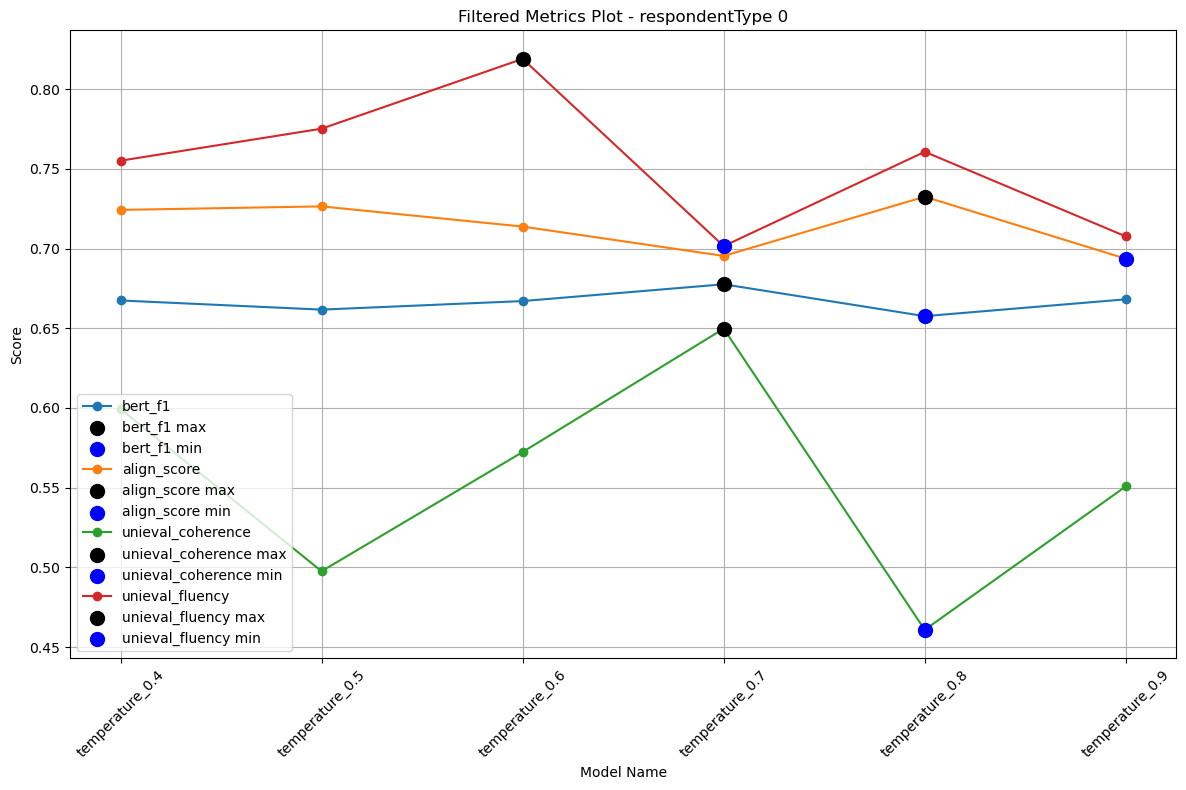

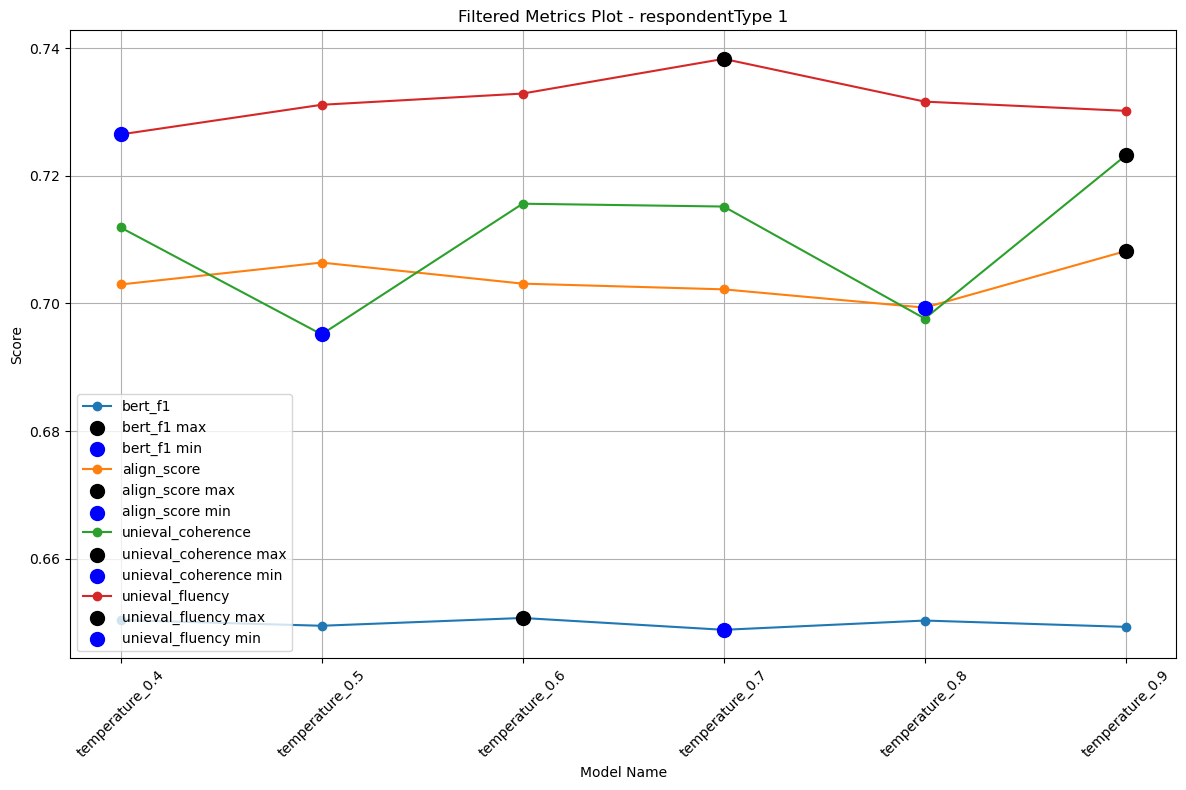

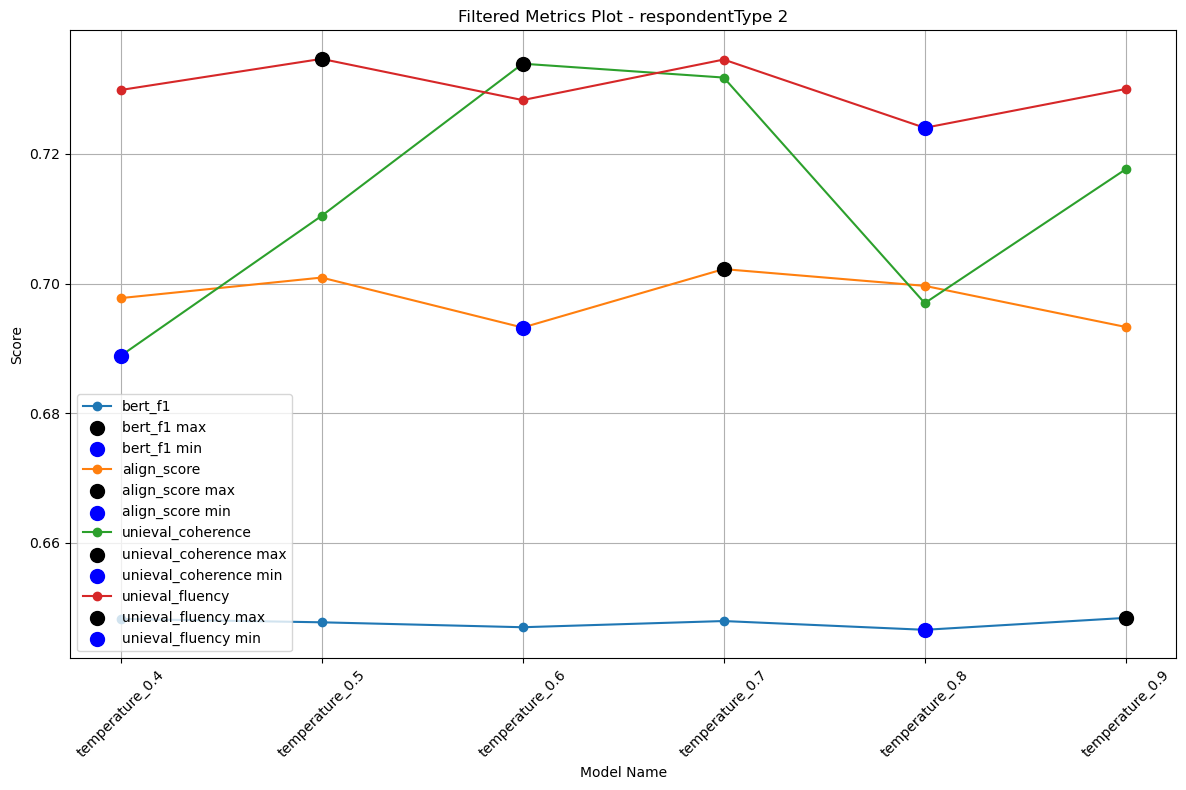

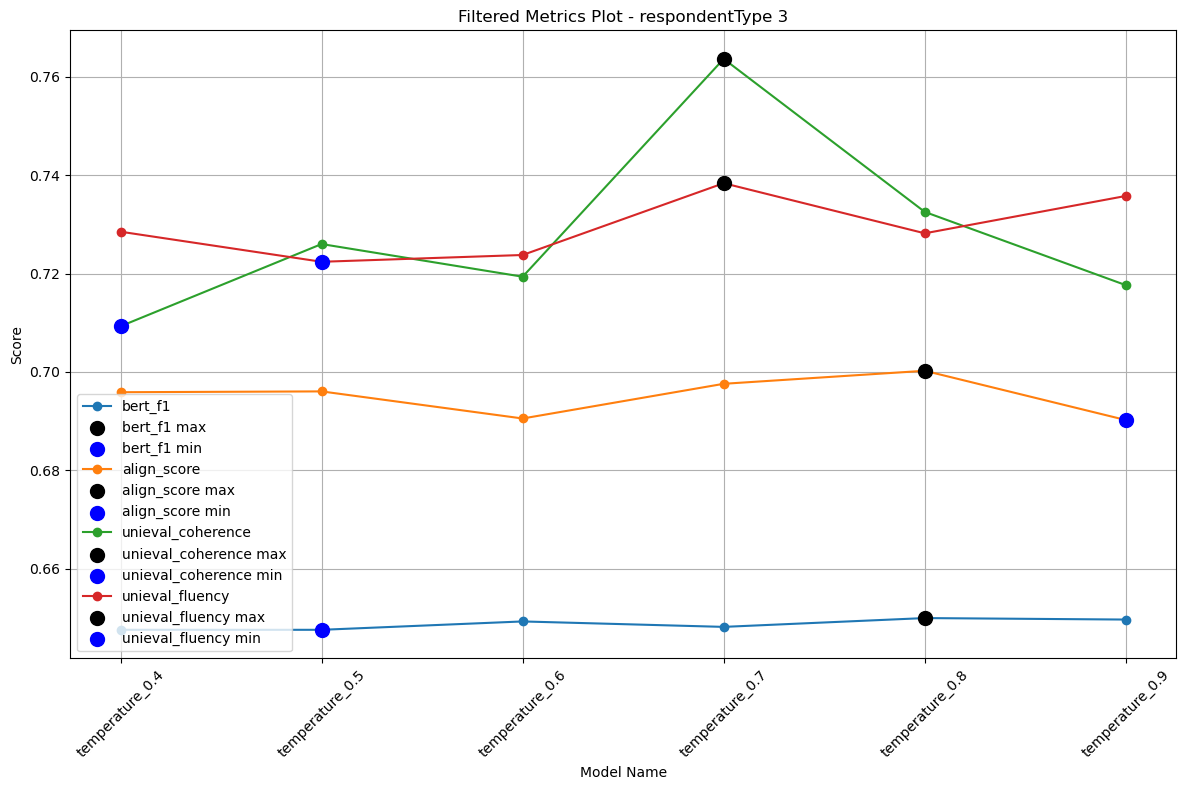

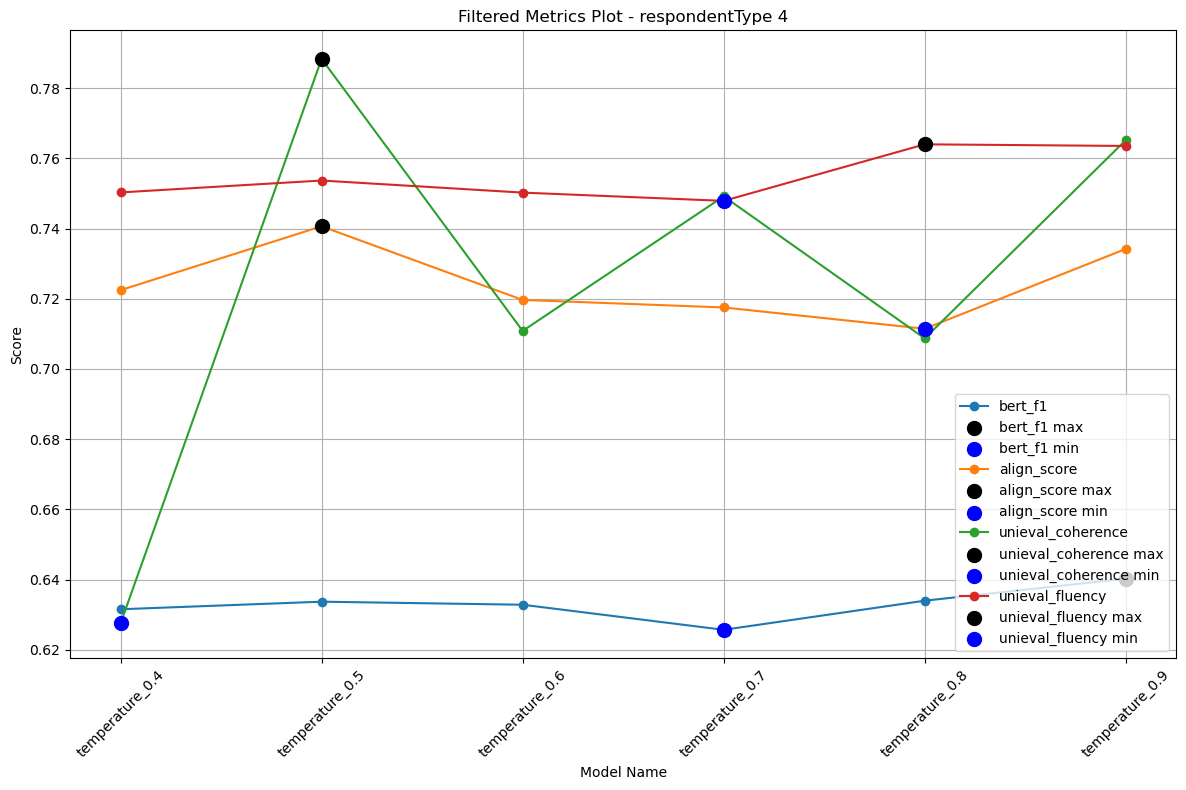

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics_from_csv(file_path, group_by_column, filter_substring, title_prefix):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)
    
    # Filter the DataFrame to include only rows where 'Model Name' contains the filter_substring
    filtered_df = df[df['Model Name'].str.contains(filter_substring)]
    
    # Drop the specified columns
    columns_to_drop = ['rougeL', 'rouge1', 'rouge2', 'unieval_relevance', 'unieval_overall', 'unieval_consistency']
    filtered_df = filtered_df.drop(columns=columns_to_drop)
    
    # Sort the DataFrame by 'Model Name'
    sorted_df = filtered_df.sort_values(by='Model Name')
    
    # Group the DataFrame by the specified column
    grouped = sorted_df.groupby(group_by_column)
    
    # Iterate over each group
    for group_name, group in grouped:
        plt.figure(figsize=(12, 8))
        for column in group.columns[2:]:  # Skip 'Model Name' and the group_by_column
            y = group[column]
            plt.plot(group['Model Name'], y, marker='o', label=column)
            
            # Highlight the maximum value
            max_value = y.max()
            max_indices = y[y == max_value].index
            plt.scatter(group['Model Name'][max_indices], y[max_indices], color='black', s=100, zorder=5, label=f'{column} max')

            # Highlight the minimum value
            min_value = y.min()
            min_indices = y[y == min_value].index
            plt.scatter(group['Model Name'][min_indices], y[min_indices], color='blue', s=100, zorder=5, label=f'{column} min')
        
        plt.title(f"{title_prefix} - {group_by_column} {group_name}")
        plt.xlabel('Model Name')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Example usage
plot_metrics_from_csv(
    '/home/mostah/workspace/fairness/scores/grouped average scores/respondentType.csv',
    'respondentType',
    'temp',
    'Filtered Metrics Plot'
)
